In [ ]:
!pip install rasterio geopandas shapely fiona

In [ ]:
import rasterio
import geopandas as gpd
from rasterio.windows import Window
from rasterio.features import rasterize
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tif_path = "/content/drive/MyDrive/AI_HACKATHON_DATA/CG_Training_dataSet_2/Training_dataSet_2/BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO.tif"

shp_path = "/content/drive/MyDrive/AI_HACKATHON_DATA/CG_SHP/shp-file/Built_Up_Area_type.shp"

In [ ]:
gdf = gpd.read_file(shp_path)

with rasterio.open(tif_path) as src:
    gdf = gdf.to_crs(src.crs)

In [ ]:
# Load shapefile and align CRS

gdf = gpd.read_file(shp_path)

with rasterio.open(tif_path) as src:
    gdf = gdf.to_crs(src.crs)

print("CRS aligned:", gdf.crs)

Reprojected SHP CRS: PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],TOWGS84[0,0,0,0,0,0,0],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]


In [ ]:
!pip install segmentation-models-pytorch albumentations opencv-python


In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class BuildingDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx].replace("img", "mask"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask


In [ ]:
!pip install -q segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,   # IMPORTANT
    in_channels=3,
    classes=1
).to(device)

In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/model/builtup_unet.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

print("Model loaded successfully 🚀")

Model loaded successfully 🚀


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/model/builtup_unet.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [ ]:
!pip install -q rasterio geopandas shapely pyproj \
              albumentations segmentation-models-pytorch \
              opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.8 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from tqdm import tqdm

In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

MODEL_PATH = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/model/builtup_unet_final.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)
model.eval()

print("✅ Built-up model loaded successfully")

✅ Built-up model loaded successfully


In [ ]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt

transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

img_path = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/data/splits/val/images/img_0.png"

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

input_tensor = transform(image=image)["image"].unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(input_tensor)
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

mask = pred.squeeze().cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Built-up Area")
plt.axis("off")

plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install geopandas rasterio shapely

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from tqdm import tqdm

In [6]:
import geopandas as gpd

gdf = gpd.read_file("/content/drive/MyDrive/AI_HACKATHON_DATA/CG_SHP/shp-file/Built_Up_Area_type.shp")

print(gdf.head())
print(gdf.columns)

   OBJECTID GlobalID Uniq_Id State_Code District_C Tehsil_Cod Block_Code  \
0         0     None    None         22        376       3370       3619   
1         0     None    None         22        376       3370       3619   
2         0     None    None         22        376       3370       3619   
3         0     None    None         22        376       3370       3619   
4         0     None    None         22        376       3370       3619   

  Village_Co LGD_Code  Built_Up_A  ...    Area_Sqm Roof_type No_Floors  \
0     450157   450157           1  ...   43.392683         1         0   
1     450157   450157           1  ...  163.208124         1         1   
2     450157   450157           1  ...   26.189821         3         2   
3     450157   450157           1  ...   21.035735         4         0   
4     450157   450157           1  ...   35.135629         3         0   

  Remarks Adl_Info  SHAPE_Leng  SHAPE_Area  GP_Code     GP_Name  \
0    None     None   43.392683 

In [ ]:
visual_mask = (mask * 60).astype('uint8')  # spread values

cv2.imwrite(f"{mask_dir}/mask_vis_{count}.png", visual_mask)

True

In [43]:
import os
import cv2
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize

tif_path = "/content/drive/MyDrive/AI_HACKATHON_DATA/CG_Training_dataSet_2/Training_dataSet_2/BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO.tif"

out_img_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/images"
out_mask_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/masks"

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

tile_size = 256
count = 0
max_tiles = 500   # change to 1000 later if needed

with rasterio.open(tif_path) as src:
    for i in range(0, src.height, tile_size):
        for j in range(0, src.width, tile_size):

            window = Window(j, i, tile_size, tile_size)
            transform = src.window_transform(window)
            bounds = rasterio.windows.bounds(window, src.transform)

            try:
                img = src.read([1, 2, 3], window=window)
            except:
                continue

            img = np.transpose(img, (1, 2, 0))

            if img.shape[0] != tile_size or img.shape[1] != tile_size:
                continue

            # polygons only inside this tile
            gdf_tile = gdf.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

            if gdf_tile.empty:
                continue

            shapes = [(geom, int(rt)) for geom, rt in zip(gdf_tile.geometry, gdf_tile["Roof_type"])]

            mask = rasterize(
                shapes,
                out_shape=(tile_size, tile_size),
                transform=transform,
                fill=0,
                dtype="uint8"
            )

            if np.sum(mask) == 0:
                continue

            # normalize image for saving
            img = img.astype(np.float32)
            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype(np.uint8)

            cv2.imwrite(os.path.join(out_img_dir, f"img_{count}.png"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            cv2.imwrite(os.path.join(out_mask_dir, f"mask_{count}.png"), mask)

            count += 1

            if count >= max_tiles:
                break
        if count >= max_tiles:
            break

print("✅ Synced dataset created")
print("Images saved:", len(os.listdir(out_img_dir)))
print("Masks saved:", len(os.listdir(out_mask_dir)))

✅ Synced dataset created
Images saved: 500
Masks saved: 500


In [44]:
import os
import cv2

src_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/masks"
vis_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/masks_visible"

os.makedirs(vis_dir, exist_ok=True)

for f in os.listdir(src_dir):
    mask = cv2.imread(os.path.join(src_dir, f), 0)
    if mask is None:
        continue
    vis = (mask * 60).astype("uint8")
    cv2.imwrite(os.path.join(vis_dir, f), vis)

print("✅ Visible masks created:", len(os.listdir(vis_dir)))

✅ Visible masks created: 500


✅ Saved at: /content/roof_classification_result.png


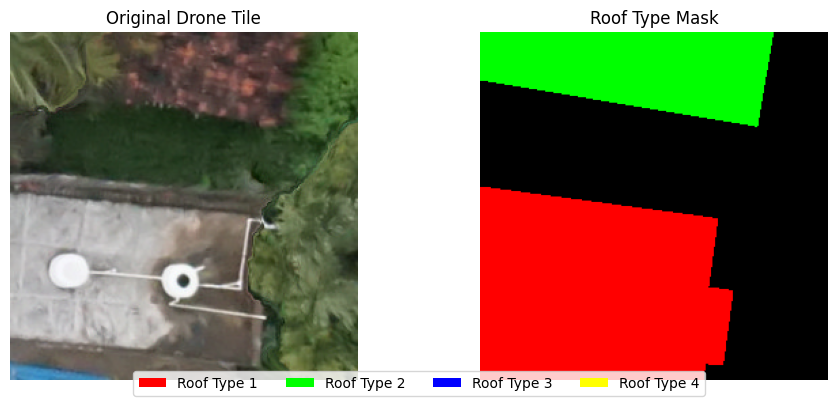

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

img_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/images"
mask_dir = "/content/drive/MyDrive/AI_HACKATHON_SUBMISSION/roof_dataset/masks"

index = 399
img_path = os.path.join(img_dir, f"img_{index}.png")
mask_path = os.path.join(mask_dir, f"mask_{index}.png")

image = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

color_map = {
    0: [0, 0, 0],
    1: [255, 0, 0],
    2: [0, 255, 0],
    3: [0, 0, 255],
    4: [255, 255, 0]
}

colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
for cls, color in color_map.items():
    colored_mask[mask == cls] = color

legend_elements = [
    Patch(facecolor=np.array(color_map[1])/255.0, label="Roof Type 1"),
    Patch(facecolor=np.array(color_map[2])/255.0, label="Roof Type 2"),
    Patch(facecolor=np.array(color_map[3])/255.0, label="Roof Type 3"),
    Patch(facecolor=np.array(color_map[4])/255.0, label="Roof Type 4"),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image)
axes[0].set_title("Original Drone Tile")
axes[0].axis("off")

axes[1].imshow(colored_mask)
axes[1].set_title("Roof Type Mask")
axes[1].axis("off")

fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
save_path = "/content/roof_classification_result.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("✅ Saved at:", save_path)
plt.show()

In [4]:
!git config --global user.name "Nithishkannan-Ganesan"

In [6]:
!git config --global user.email "nithishkannan298@gmail.com"
!git clone https://github.com/Nithishkannan-Ganesan/Geospatial-Hackathon.git

Cloning into 'Geospatial-Hackathon'...
fatal: could not read Username for 'https://github.com': No such device or address
